In [1]:
# =========================================
# 📚 IMPORT ALL REQUIRED LIBRARIES (TOP CELL)
# =========================================

# Data handling
import pandas as pd
import numpy as np

# Text processing
import re

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Models 
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import accuracy_score, classification_report
# Save model
import joblib
from sklearn.model_selection import cross_val_score
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
import random
from sklearn.model_selection import learning_curve



In [2]:
#LOAD DATASET

In [3]:
# Load
data = pd.read_csv(
    "../datasets/tigrigna_translated_news_dataset(5).csv",
    encoding="utf-8-sig",   # 👈 IMPORTANT FIX
    sep=None,
    engine="python"
)

# Clean column names
data.columns = data.columns.str.strip()

# Inspect
print("Columns:", list(data.columns))

# Rename properly (adjust based on output)
data.columns = data.columns.str.replace('\ufeff', '', regex=True).str.strip()

data.rename(columns=lambda x: x.strip().lower(), inplace=True)

data.rename(columns={
    'tigrigna_translated_text': 'text',
    'label': 'label'
}, inplace=True)

print(data.columns)
print(data[['text']].head())

Columns: ['Tigrigna_translated_text', 'label']
Index(['text', 'label'], dtype='object')
                                                text
0  ላዕለዋይ ቤት ፍርዲ ማሳቹሰትስ ብዛዕባ ማእሰርቲ ስደተኛታት ዝሃቦ ውሳነ ...
1  ኣመሪካ ብሰንኪ እቲ ኣብ ልዕሊ ዘይመንግስታውያን ትካላት ዝተወሰነ ቀይዲ፡...
2  ረክስ ቲለርሰን ካብ ስልጣኖም ከምዘይለቁን ምስ ትራምፕ ጽቡቕ ርክብ ከምዘ...
3  ኣባላት ኮንግረስ ኣመሪካ ኣብ ልዕሊ ሩስያ ሓድሽ እገዳ ንምንባር ተሰማሚዖ...
4  ዶናልድ ትራምፕ ንገዛኢ ክፍለ-ሃገር ካንሳስ ሳም ብራውንባክ ኣምባሳደር ኣ...


In [4]:
import re

# ===============================
# 🧹 TEXT CLEANING FUNCTION (IMPROVED)
# ===============================

def clean_text(text):
    text = str(text)

    # ===========================
    # 1. Remove URLs
    # ===========================
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # ===========================
    # 2. Remove email addresses
    # ===========================
    text = re.sub(r'\S+@\S+', '', text)

    # ===========================
    # 3. Remove Tigrigna punctuation
    # ===========================
    text = re.sub(r'[።፣፤፥፦፧፨]', '', text)

    # ===========================
    # 4. Remove English punctuation + symbols
    # ===========================
    text = re.sub(r'[.,;:!?()\[\]{}"\'`~@#$%^&*+=|\\/<>_-]', '', text)

    # ===========================
    # 5. Remove digits (Arabic + Western)
    # ===========================
    text = re.sub(r'[0-9\u1369-\u137C]', '', text)

    # ===========================
    # 6. Remove extra noise characters (safe Unicode filter)
    # ===========================
    text = re.sub(r'[^\w\s\u1200-\u137F]', '', text)

    # ===========================
    # 7. Normalize spaces
    # ===========================
    text = re.sub(r'\s+', ' ', text)

    return text.strip()


# Apply to dataset
data['clean_text'] = data['text'].apply(clean_text)

In [5]:
# ===============================
# 🧹 CLEAN LABELS (STRONG VERSION)
# ===============================

# Remove missing values early
data = data.dropna(subset=['text', 'label'])

# Convert label to numeric
data['label'] = pd.to_numeric(data['label'], errors='coerce')

# Drop invalid rows again
data = data.dropna(subset=['label'])

# Convert to int
data['label'] = data['label'].astype(int)

# Define X and y AFTER cleaning
X = data['text']
y = data['label']

print("Remaining NaN:", data['label'].isnull().sum())
print("Label values:", data['label'].unique())

Remaining NaN: 0
Label values: [1 0]


In [6]:
def normalize_tigrigna(text):
    text = str(text).strip()   # ✔ move strip HERE

    replacements = {
        "አ": "ኣ", "ዐ": "ኣ",
        "ሐ": "ሀ", "ኀ": "ሀ", "ሓ": "ሀ",
        "ሰ": "ሠ", "ሸ": "ሠ",
        "ጸ": "ፀ",
        "ከ": "ካ", "ኸ": "ካ",
        "ዘ": "ዠ",
        "ደ": "ዳ",
        "ገ": "ጋ",
        "በ": "ባ",
        "ፐ": "ፓ",
        "ኡ": "ኢ", "ኤ": "ኢ", "እ": "ኢ", "ኦ": "ኢ",
        "፡": " ",
    }

    for k, v in replacements.items():
        text = text.replace(k, v)

    return text

In [7]:
data['clean_text'] = data['clean_text'].apply(normalize_tigrigna)

In [8]:
# Tokenization function
def tokenize(text):
    return re.findall(r'[A-Za-z]+|[ሀ-፿]+', text)

# Apply tokenization
data['tokens'] = data['clean_text'].apply(tokenize)

# Stopwords
stopwords = set([
"ኣነ","ንስኻ","ንስኺ","ንሱ","ንሳ","ንሕና","ንሳቶም","ንኣይ","ንእሱ","ንእሳ","ንእኛ","ንእኦም",
"እዚ","እቲ","እታ","እቶም","እዞም","እዚኣ","እቲኣ",
"እና","ወይ","ግን","ምኽንያቱ","ስለዚ","እኳ","እንተ","እንከ","እውን","ደጊም",
"ኣብ","ናብ","ካብ","ምስ","ብዘይ","ብዛዕባ","ን","ናይ","ብ","ላዕሊ","ታሕቲ",
"እዩ","እየ","እዮም","ነበረ","ነበሩ","ክኸውን","ኣለኒ","ኣለዎ","ኣለዋ","ኣሎ","ኣሎም",
"ግበር","ይገብር","ገበረ","ክኽእል","ክ","ምናልባት",
"ኣይ","የለን","ከቶ","ምንም","ዋላ","ኣይኮነን",
"ኩሉ","ብዙሕ","ሓደ","ገለ","ዝኾነ","ነፍሲ","ወከፍ","ዝያዳ","ንእሽቶ",
"ሕጂ","ከዚ","ቅድሚ","ድሕሪ","ኩሉ","ግዜ","ንኣንስ","ብዙሕ","ግዜ","ከቶ",
"ብቻ","ጥራይ","እውን","እኳ","ኣብዚ","ኣብቲ","ስለምንታይ","ከመይ","እንታይ","መን","ኣበይ",
"እዚኦም","እቶም","እዚኣቶም","እቲኦም","እዚኦን",
"ኣሎኹም","ኣለና","ኣሎኻ","ኣሎኺ","ኣሎኹ",
"ከም","ከምዚ","ከምኡ","ከምዚኦም","ከምኡን",
"ስለ","ስለዚ","ስለዚኣ","ስለዚኦም",
"ዝ","ዝኾነ","ዝኾነን","ዝኾነኦም",
"እንተኾነ","እንተዘይኮነ","እንተዘይ",
"ኣብዚኣ","ኣብዚኦም","ኣብቲኦም",
"ብዚ","ብኡ","ብዚኦም",
"ካብዚ","ካብኡ","ካብኦም",
"ናብዚ","ናብኡ","ናብኦም",
"ምስዚ","ምስኡ","ምስኦም",
"ብዙሕ","ግዜ","ኣንስ","ኩሉ","ግዜ","ሓደ","ግዜ",
"ድሕሪኡ","ቅድሚኡ","ሕጂኡ",
"እዚኣ","እዚኦም","እቲኦም","እታኦም",
"ኣይኮነን","ኣይኮነንን","ኣይኮነንንን",
"ኣሎን","የለንን","ኣሎንን",
"ሓደ","ሓደን","ሓደንን",
"ከምዚ","ከምኡ","ከምኡን","ከምዚን",
"እንተ","እንተኾነ","እንተዘይ","እንተዘይኮነ",
"እዚ","እቲ","እታ","እቶም","እዞም",
"ዝ","ዝኾነ","ዝኾነን",
"እና","እናደር","እናበለ","እናሃበ",
"እውን","ደጊም","እኳ","እኳን",
"ን","ናይ","ብ","ኣብ","ካብ","ናብ",
"እንታይ","መን","ከመይ","ኣበይ",
"እዚኣ","እቲኣ","እታኣ","እቶምኣ",
"ክ","ክኸውን","ክግበር","ክኽእል",
"ምናልባት","ከምዚ","ከምኡ",
"እዩ","እየ","እዮም","እዩን","እየን",
"ነበረ","ነበሩ","ነበርኩም","ነበርና",
"ኣሎ","ኣለ","ኣሎም","ኣሎን","ኣሎኻ","ኣሎኺ",
"የለን","የለንን","የለንንን",
"ከቶ","ምንም","ዋላ","ዋላኳ",
"ኩሉ","ገለ","ሓደ","ብዙሕ","ንእሽቶ",
"ኩሉ","ግዜ","ብዙሕ","ግዜ","ንኣንስ","ግዜ",
"ሕጂ","ከዚ","ቅድሚ","ድሕሪ","እንከ",
"ኣብዚ","ኣብቲ","ኣብዚኣ","እምበር","ይኹን","ኣብቲኣ","ከምዘሎ"
])

# Clean tokens function
def clean_tokens(tokens):
    return [word for word in tokens if word not in stopwords]

# Apply stopword removal
data['tokens'] = data['tokens'].apply(clean_tokens)

# Join tokens into text
data['processed_text'] = data['tokens'].apply(lambda x: " ".join(x))

In [9]:
print(data['tokens'].iloc[7])

['ምምሕዳር', 'ትራምፕ', 'ስምምዕ', 'ናፍታ', 'NAFTA', 'ምትኢስሳር', 'ባጤራ', 'ንምቁጽጻር', 'መምርሒ', 'ክውስኽ', 'ይሀስብ', 'ዋሽንግተን', 'ሮይተርስ', 'ሚኒስተር', 'ፋይናንስ', 'ኣመሪካ', 'ስቲቨን', 'ምኑቺን', 'ሀሙስ', 'ካም', 'ዝጋለጽዎ', 'ምምሕዳር', 'ትራምፕ', 'ካም', 'ኣካል', 'ናይቲ', 'ንመጻኢ', 'ዝግባሩ', 'ነጻ', 'ንግዲ', 'ስምምዓት', 'መዳቡ', 'ሠሜን', 'ኣመሪካ', 'ነጻ', 'ንግዲ', 'ስምምዕ', 'NAFTA', 'ምትኢስሳር', 'ባጤራ', 'currency', 'manipulation', 'ንምክልኻል', 'ዠኽኢል', 'መምርሒ', 'ንምኢታው', 'ይጽዕር', 'ካምዠሎ', 'ሀቢሮም', 'ምኑቺን', 'ኮሚቴ', 'ፋይናንሳዊ', 'ኣጋልግሎት', 'ቤት', 'ምኽሪ', 'ወካልቲ', 'ህዝቢ', 'ዝሃብዎ', 'ቃል', 'ብወጋን', 'መሻርኽቲ', 'ንግዲ', 'ኣመሪካ', 'ዝግባር', 'ባጤራ', 'ምትኢስሳር', 'ብተግባር', 'ዝርኣ', 'ሳዕቤን', 'ክህልዎ', 'ካም', 'ዝግባኢ', 'ኢምባር', 'ብዠረባ', 'ክካውን', 'ካምዠይብሉ', 'ጋሊጾም', 'ንሶም', 'ወሲኾም', 'ካም', 'ዝባልዎ', 'ትካል', 'ኣህጉራዊ', 'ቁጠባ', 'ፒተርሠን', 'Peterson', 'Institute', 'for', 'International', 'Economics', 'ዝቐረባ', 'ሀሳብ', 'ማለት', 'ሚኒስትሪ', 'ፋይናንስ', 'ነቲ', 'ብፍላጥ', 'ክወርድ', 'ዝግባር', 'ዠሎ', 'ሀንቲ', 'ሃጋር', 'ባጤራ', 'ብምዕዳግ', 'ጣልቃ', 'ንክኣቱ', 'countervailing', 'currency', 'interventions', 'ዝግባር', 'ጻዕሪ', 'ሀዳ', 'ካብቶም', 'ብዙሀት', 'ኣማራጺታት', 'ክካውን', 'ይኽኢል', 'ኢዩ', 'ኢምባር', 'ምኑ

In [10]:
print("እውን" in data['tokens'].iloc[8])
print("ይኹን" in data['tokens'].iloc[8])

False
False


In [11]:

X = data['processed_text']
y = data['label']
print(data['processed_text'].iloc[14])

ፑቲን ዋሽንግተን ሀድሽ ኢጋዳታት ኢንተቀጺላ ሩስያ ግብረመልሲ ክትህብ ምዃና ኣጠንቂቖም ሳቮንሊና ፊንላንድ ሮይተርስ ፕረዚዳንት ቭላድሚር ፑቲን ሀሙስ ካም ዝጋለጽዎ ዋሽንግተን ነቲ ዠይሕጋዊ ሀድሽ ኢጋዳታት ዝባልዎ ልዕሊ ሞስኮ ኢንተዳፍኣሉ ሩስያ ግብረመልሲ ክትህብ ክትግዳድ ምዃና ጋሊጾም ንተግባር ኣመሪካ ልዕሊ ሃጋሮም ድማ ብልሀት ዠይብሉን ዠይርትዓውን boorish and unreasonable ክብሉ ጋሊጾምዎ ፑቲን ፊንላንድ ዝጋባርዎ ምብጻሕ ኢቲ ሠሉስ ብቤት ምኽሪ ወካልቲ ህዝቢ ኣመሪካ House of Representatives ዝሀለፈ ልዕሊ ሩስያ ሀድሽ ኢጋዳታት ንምንባርን ፕረዚዳንት ዶናልድ ትራምፕ ኢጋዳታት ምፍካሶም ኣባላት ኮንግረስ ፍቓድ ክሀትቱ ዠጋድድን ውሳነ ርኢይቶ ሂቦም ኣለዉ ኢቲ ኢጋዳታት ጋና ብሠነድ ብትራምፕ ኣይፀዳቐን ሀዳ ላዕለዋይ ባዓል ስልጣን ዋይት ሃውስ ድማ ሀሙስ ካም ዝባሎ ትራምፕ ሀያል ስምምዕ ንምርካብ ነቲ ሕጊ መሠል ቪቶ veto ተጠቒሞም ክዓግትዎ ይኽኢሉ ኢዮም ፑቲን ሩስያ ዝሀለፈ ዓመት ምርጫ ፕረዚዳንት ኣመሪካ ኢዳ ኣኢትያ ኢያ ንዝብል ክሲ ዳጋጊሞም ዝነፀጉ ኮይኖም ሞስኮ ብካመይ ግብረመልሲ ካም ኢትህብ ክትውስን ኢትኽኢል ኢቲ ዝቐረባ ረቂቕ ሕጊ መወዳኢታ ትሕዝቶኢ ረኣየት ምዃኑ ጋሊጾም ካም ኢትፈልጥዎ ዓቕልን ትዕግስትን ንጋብር ኢንተኾነ ጋለ ኢዋን ግብረመልሲ ክንህብ ክንጋዳድ ኢና ነዚ ልዕሊ ሃጋርና ዝግባር ዠሎ ድንቁርና ንዠልኣለም ክንዕጋሶ ኣይካኣልን ኢዩ ክብሉ ፑቲን ምስቲ ፊንላንዳዊ መዠንኢም ዝሃብዎ ሀባራዊ ጋዜጣዊ መግለጺ ተዛሪቦም መልስና መዓስ ክካውን ኢዩ ኢንታይካ ክካውን ኢዩ ኢዚ ሠነድ ኣመሪካ ዝዝተየሉ ዠሎ መወዳኢታ ትሕዝቶ ኢቲ ረቂቕ ሕጊ ክምርኮስ ኢዩ ፑቲን ብተወሳኺ ኢቲ ዝሀለፈ ታሕሳስ ጀሚሩ መንጎ ሞስኮን ዋሽንግተንን ዠሎ ዲ

In [12]:
# ===============================
# ✂️ TRAIN-TEST SPLIT
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,stratify=y
)


In [13]:
assert y_train.isnull().sum() == 0, "Still contains NaN!"

In [14]:
print("y_train NaN:", y_train.isnull().sum())

y_train NaN: 0


In [15]:
print(X_train.shape)
print(X_test.shape)

(2401,)
(601,)


In [16]:
# ===============================
#TF-IDF (Term Frequency – Inverse Document Frequency)
# 🎯 DEFINE FEATURES AND LABEL
# ===============================



In [17]:

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
print(len(X_train), len(y_train))
print(len(X_test), len(y_test))
print(X_train_vec.shape[0], len(y_train))
print(X_train_vec.shape)
print(X_test_vec.shape)

2401 2401
601 601
2401 2401
(2401, 5000)
(601, 5000)


In [18]:
#MODEL TRAINING (Fake News Classifier) 

In [19]:
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

nb_pred = nb_model.predict(X_test_vec)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.9251247920133111
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       301
           1       0.94      0.91      0.92       300

    accuracy                           0.93       601
   macro avg       0.93      0.93      0.93       601
weighted avg       0.93      0.93      0.93       601



In [20]:
# ===============================
# 🤖 LOGISTIC REGRESSION
# ===============================

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_vec, y_train)

lr_pred = lr_model.predict(X_test_vec)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.9550748752079867
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       301
           1       0.97      0.94      0.95       300

    accuracy                           0.96       601
   macro avg       0.96      0.96      0.96       601
weighted avg       0.96      0.96      0.96       601



In [50]:
param_grid = {
    'C': [0.1, 1, 5, 10]
}

grid = GridSearchCV(
    LinearSVC(class_weight='balanced', dual='auto'),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid.fit(X_train_vec, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'C': 1}
Best Score: 0.9604327923429047


In [51]:
# ===============================
# 🤖 SVM MODEL (STRONG MODEL)
# ===============================
best_svm = grid.best_estimator_

svm_pred = best_svm.predict(X_test_vec)
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.9667221297836939
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       301
           1       0.97      0.96      0.97       300

    accuracy                           0.97       601
   macro avg       0.97      0.97      0.97       601
weighted avg       0.97      0.97      0.97       601



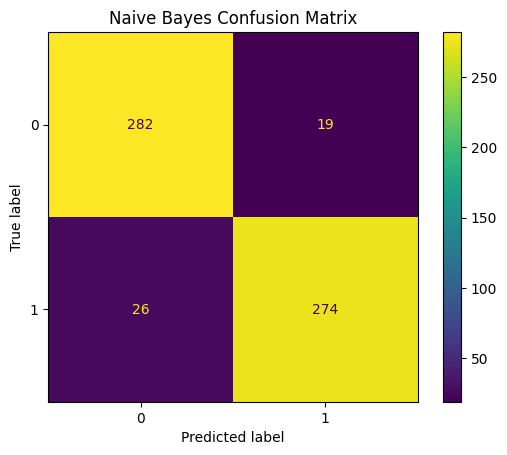

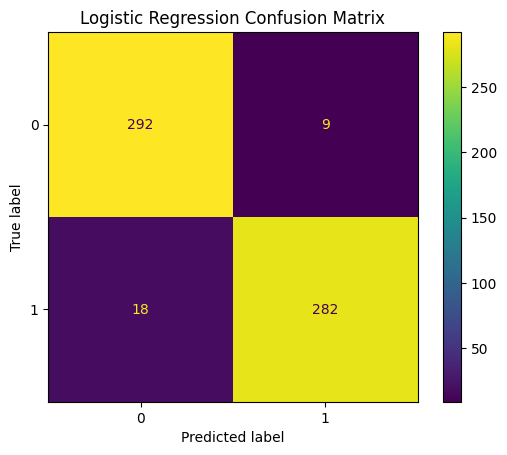

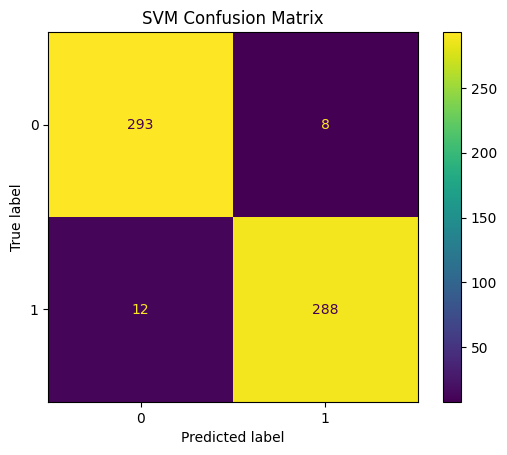

In [52]:
# ===============================
# 📊 ALL CONFUSION MATRICES
# ===============================

models = {
    "Naive Bayes": nb_pred,
    "Logistic Regression": lr_pred,
    "SVM": svm_pred
}

for name, pred in models.items():
    cm = confusion_matrix(y_test, pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    
    plt.title(f"{name} Confusion Matrix")
    plt.show()

In [53]:
print("\nNaive Bayes Report:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))
print("\nLogistic Regression Report:",accuracy_score(y_test,lr_pred))
print(classification_report(y_test, lr_pred))
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))


Naive Bayes Report: 0.9251247920133111
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       301
           1       0.94      0.91      0.92       300

    accuracy                           0.93       601
   macro avg       0.93      0.93      0.93       601
weighted avg       0.93      0.93      0.93       601


Logistic Regression Report: 0.9550748752079867
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       301
           1       0.97      0.94      0.95       300

    accuracy                           0.96       601
   macro avg       0.96      0.96      0.96       601
weighted avg       0.96      0.96      0.96       601

SVM Accuracy: 0.9667221297836939
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       301
           1       0.97      0.96      0.97       300

    accuracy                           0.97       601
   macr

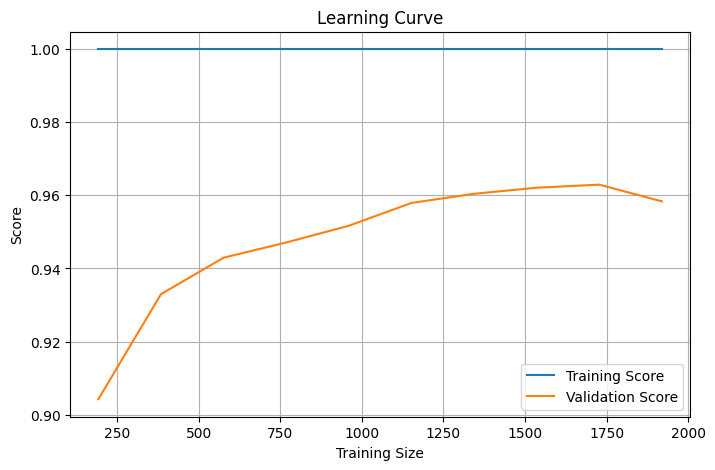

In [54]:


train_sizes = np.linspace(0.1, 1.0, 10)

train_sizes_abs, train_scores, test_scores = learning_curve(
    best_svm,
    X_train_vec,
    y_train,
    train_sizes=train_sizes,
    cv=5,
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(train_sizes_abs, train_mean, label="Training Score")
plt.plot(train_sizes_abs, test_mean, label="Validation Score")

plt.title("Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Score")
plt.legend()

plt.grid()
plt.show()

In [55]:
# ===============================
# 📊 MODEL COMPARISON TABLE
# ===============================

model_names = ["Naive Bayes", "Logistic Regression", "SVM"]

accuracies = [
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, svm_pred)
]

comparison_df = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracies
})

print(comparison_df)

                 Model  Accuracy
0          Naive Bayes  0.925125
1  Logistic Regression  0.955075
2                  SVM  0.966722


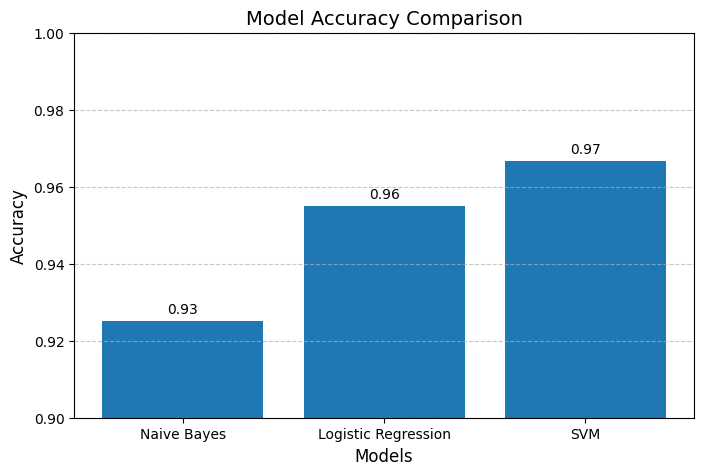

In [56]:
# ===============================
# 📈 PROFESSIONAL MODEL COMPARISON GRAPH
# ===============================

plt.figure(figsize=(8, 5))

bars = plt.bar(model_names, accuracies)

plt.title("Model Accuracy Comparison", fontsize=14)
plt.xlabel("Models", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

# Add value labels on top of bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.002, f"{v:.2f}", ha='center', fontsize=10)

plt.ylim(0.9, 1.0)  # zoom into accuracy range for clarity

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

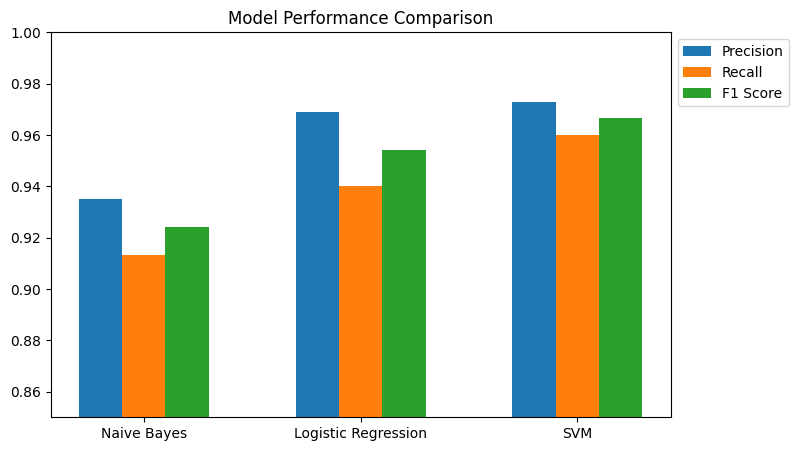

In [57]:
# ===============================
# 📊 PRECISION / RECALL / F1 GRAPH
# ===============================

from sklearn.metrics import precision_score, recall_score, f1_score

precision = [
    precision_score(y_test, nb_pred),
    precision_score(y_test, lr_pred),
    precision_score(y_test, svm_pred)
]

recall = [
    recall_score(y_test, nb_pred),
    recall_score(y_test, lr_pred),
    recall_score(y_test, svm_pred)
]

f1 = [
    f1_score(y_test, nb_pred),
    f1_score(y_test, lr_pred),
    f1_score(y_test, svm_pred)
]

x = np.arange(len(model_names))

plt.figure(figsize=(8,5))
plt.ylim(0.85, 1.0)

plt.bar(x - 0.2, precision, width=0.2, label="Precision")
plt.bar(x, recall, width=0.2, label="Recall")
plt.bar(x + 0.2, f1, width=0.2, label="F1 Score")

plt.xticks(x, model_names)
plt.title("Model Performance Comparison")
plt.legend(loc='upper left', bbox_to_anchor=(1,1))

plt.show()

In [60]:
best_model = comparison_df.loc[comparison_df['Accuracy'].idxmax()]
print("Best Model:", best_model["Model"])
print("Best Accuracy:", best_model["Accuracy"])

Best Model: SVM
Best Accuracy: 0.9667221297836939


In [61]:
scores = cross_val_score(best_svm, X_train_vec, y_train, cv=5)

print("SVM Cross Validation Accuracy:", scores.mean())

SVM Cross Validation Accuracy: 0.9583497920997921


In [62]:
# ===============================
# 🔍 RANDOM TEST FROM DATASET
# ===============================


def predict_news(text):
    processed = text
    
    # If you still want preprocessing:
    tokens = tokenize(text)
    tokens = clean_tokens(tokens)
    processed = " ".join(tokens)

    vec = vectorizer.transform([processed])

    pred = best_svm.predict(vec)

    return "REAL" if pred[0] == 1 else "FAKE"

In [63]:
def predict_with_confidence(text):
    tokens = tokenize(text)
    tokens = clean_tokens(tokens)
    processed = " ".join(tokens)

    vec = vectorizer.transform([processed])

    decision = best_svm.decision_function(vec)[0]
    prediction = best_svm.predict(vec)[0]

    return prediction, decision

In [64]:
for i in range(5):
    idx = random.randint(0, len(data)-1)

    text = data['processed_text'].iloc[idx]
    actual = data['label'].iloc[idx]

    prediction = predict_news(text)

    print("\n📝 TEXT:", text[:1000], "...")
    print("✅ ACTUAL:", "REAL" if actual == 1 else "FAKE")
    print("🤖 PREDICTED:", prediction)


📝 TEXT: ዋሽንግተን ሮይተርስ ሚኒስተር ፍትሒ ኣመሪካ ጀፍ ሴሽንስ ረቡዕ ፕረዚዳንት ዶናልድ ትራምፕ ሩስያ ዠካየዶ ዝርርብ ንዝቐረባሉ ሕቶታት መልሲ ንምሃብ ኣብዪ ኢዋን ወፍሪ ምርጫ ሩስያውያን ዝነባሮ ርክብ ንኮንግረስ ሀሶት ተዛሪቡ ንዝብል ክሲ ድማ ነጺግዎ ሴሽንስ ምስቶም ሠኔት ዠለዉ ዳሞክራውያን ዝጋባሮ ወጥሪ ዝመልኢ ክርክር መጀመርታ ኢዚ ዓመት ዝተኻየዳ ስልጣን መጽዳቂ መድረኽ ሠባስልጣን ሩስያ ኣይተራካብኩን ብምባሉ ንዓታቶም ካም ዠየታለለ ጋሊጹ ሴሽንስ ምክትታል መድረኽ ኮሚቴ ጉዳያት ፍርዲ ሠኔት ኢቲ ወፍሪ ምርጫ ብዝምልካት ሩስያውያን ዠይግቡኢ ዝርርብ ኣየካየድኩን ኢሉ ተዛሪቡ ሴሽንስ ኣምባሳዳር ሩስያ ሠርጌይ ኪስልያክ ኢንተወሀዳ ክልተ ካም ዝተራካባ ወርሒ መጋቢት ምቅልዑ ካብቲ ሩስያ ምርጫ ዠርኣየቶ ኢድኣኢታውነትን ኣማካርቲ ትራምፕ ክህልዎ ዝኽኢል ምስጢራዊ ስምምዕን ዝግባር ምርመራታት ባዕሉ ንክኢለ ተጋዲዱ ኢዩ ጋዜጣ ዋሽንግተን ፖስት ወርሒ ሀምለ ካም ዝፀብፀባቶ ትካላት ስለያ ኣመሪካ ኪስልያክ ሴሽንስ ኣቕዋም ትራምፕ ርክብ ኣመሪካን ሩስያን ዓሚቕ ዝርርብ ካም ዝጋባረ ንክረምሊን Kremlin ክጋልጽ ካሎ ዝተታሕዠ ድምጺ ረኺቦም ኢዮም ሴሽንስ ረቡዕ ካም ዝጋለጾ ዝርዝር ትሕዝቶ ኢቲ ዝርርብ ክዝክሮ ካም ዠይክኢል ሀቢሩ ዝርዝር ናይቲ ወፍሪ ምርጫ ዝርርብ ዝነባረ ኣይመስለንን ኢሉ ቤት ጽሕፈተይ ዋዕላ ዝነባረ ርክብ ኣቕዋም ትራምፕ ጋለ ርኢይቶታት ተዋሂቡ ክካውን ይኽኢል ኢዩ ኢዚ ዝካኣል ኢዩ ኢለ ኢየ ዝሀስብ ክብል ወሲኹ ጋሊጹ ዳሞክራታዊ ሴነተር ፓትሪክ ሌሂ ንሴሽንስ ካም ዝጋለጾ ብርክት ዝባሉ ኣባላት ኢቲ ኮሚቴ ሴሽንስ ሩስያውያን ምርኻቡ ክኽሕድ ካሎ ሀሶት ምስክርነት ካም ዝሃባ ኢዮም ዝኣምኑ ሴሽንስ ኢቲ ሕቶ ምስቲ ምርጫ ምትኢትታው ዝተኣሳሠር ካም ዝመሠሎን 

In [65]:
# ===============================
# ❌ SHOW WRONG PREDICTIONS
# ===============================

wrong = []

for i in range(len(X_test)):
    pred = best_svm.predict(X_test_vec[i])
    actual = y_test.iloc[i]

    if pred != actual:
        wrong.append(i)

print("Total wrong predictions:", len(wrong))

Total wrong predictions: 20


In [66]:
for i in wrong[:5]:
    print("\n📝 TEXT:", X_test.iloc[i][:1000])
    print("❌ ACTUAL:", y_test.iloc[i])
    print("🤖 PREDICTED:", best_svm.predict(X_test_vec[i])[0])


📝 TEXT: ዋሽንግተን ሮይተርስ ኢቲ ቸክ ተላኢኹ ኢዩ ኢዚ ድማ ሀዳ ኣቦ ዝተቐትለ ኣመሪካ ሠራዊት ሳርጀንት ፕረዚዳንት ዶናልድ ትራምፕ ዝኣተዎ ልግስና ዝመልኢ ቃል ኣይተተግባረን ምባሉ ዋይት ሃውስ ረቡዕ ዝሃቦ መልሲ ኢዩ ክሪስ ባልድሪጅ ንጋዜጣ ዋሽንግተን ፖስት Washington Post ካም ዝጋለጾ ትራምፕ ብሠንኪ ሀዳ ኣፍጋኒስታን ፖሊስ መኮነን ወርሒ ሠነ ንዝተቐትለ ወዲ ዓመት ወዱ ንስድራቤቱ ዶላር ክህቦም ቃል ኣትዩሎም ነይሩ ኢንተኾነ ኢቲ ጋንዠብ ካም ዠይባጽሀ ነታ ጋዜጣ ነጊርዋ ሀንቲ ወሃቢት ቃል ዋይት ሃውስ ረቡዕ ካም ዝጋለፀቶ መራካቢ ብዙሃን ነዚ ባልድሪጅ ዛንታ ብምስዓብ ኣቐዲምካ ዝተታሕዠ ጽልኢ biased agenda የቃልሑ ኣለዉ ኢላ ወሃቢ ቃል ዋይት ሃውስ ሊንድሠይ ዎልተር ባኢመይል ዝሃባቶ መልሲ ኢቲ ቸክ ተላኢኹ ኢዩ ኢላ መራካቢ ብዙሃን ነቲ ብፕረዚዳንት ብውልቂ ዝተጋብረ ልግስናን ቅኑዕ ምንቅስቓስን ተጠቒሞም ጽልኢ ዠለዎ ኣጀንዳኢም ንምስጓም ምጥቃሞም ዠፈንፍን ኢዩ ክትብል ድማ ወሲኻ ኢዚ ጉዳይ ኢዚ ትራምፕ ንዝተቐትሉ ወተሃዳራት ንዝወለዱ ስድራቤታት ዝሃቦ መልሲ ንዝተላዕለ ምስሕሀብ ተወሳኺ ኮይኑ ሶኑ ትራምፕ ጋለ ካብቶም ቅድሚኢ ዝነባሩ ፕረዚዳንታት ንዝተቐትሉ ወተሃዳራት ስድራቤታት ንምጽንናዕ ነጋር ኣይጋባሩን ምባሉ ሠፊሕ ነቐፌታ ኣስዒቡ ኢዩ ትራምፕ ንዝተዛረቦ ጭቡጥ መርትዖ ኣየቕረባን ኢቲ ዝባሎ ድማ ብኢንብኢ ሀሶት ምዃኑ ተረጋጊጹ ኢዩ ረቡዕ ትራምፕ ነቲ ወኪል ፍሎሪዳ ፍረዳሪካ ዊልሠን ዝሃባቶ ሀባሬታ ነጺግዎ ኢዩ ዊልሠን ትራምፕ ነታ ኒጀር ብጥይት ንዝተቐትለ ሳርጀንት ላ ዴቪድ ቲ ጆንሠን መባለት ኢቲ ወተሃዳራት ንምንታይ ካም ዝተመዝጋባ ይፈልጥ ነይሩ ኢዩ ካም ዝባላ ጋሊጻ ነይራ ትራምፕ ረቡዕ ንጋዜጠኛታት ኢታ ወኪል ኮንግረስ ዝባለቶ ኣይባልኩን 

In [67]:
scores = cross_val_score(best_svm, X_train_vec, y_train, cv=5)

print("Cross-validation scores:", scores)
print("Average:", scores.mean())

Cross-validation scores: [0.96049896 0.96458333 0.96458333 0.94791667 0.95416667]
Average: 0.9583497920997921


In [68]:
print("Before saving:")
print("Has IDF:", hasattr(vectorizer, "idf_"))

Before saving:
Has IDF: True


In [69]:
import os

os.makedirs("models", exist_ok=True)

In [70]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

pipeline = Pipeline([
    ("vectorizer", TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ("model", LinearSVC(class_weight='balanced', C=1, dual='auto'))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
                ('model',
                 LinearSVC(C=1, class_weight='balanced', dual='auto'))])

In [71]:
# import os

# # Go to project root (one level up from notebooks)
# BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))

# # Correct models folder
# MODEL_DIR = os.path.join(BASE_DIR, "models")

# # Create folder if not exists
# os.makedirs(MODEL_DIR, exist_ok=True)

In [72]:
# joblib.dump(pipeline, os.path.join(MODEL_DIR, "pipeline.pkl"))

# print("✅ Pipeline saved at:", os.path.join(MODEL_DIR, "pipeline.pkl"))

In [73]:
# p = joblib.load(os.path.join(MODEL_DIR, "pipeline.pkl"))

# print("Has IDF:", hasattr(p.named_steps["vectorizer"], "idf_"))
# print("Test prediction:", p.predict(["test news"]))

In [74]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
import joblib
import os

# Use raw processed text (NOT vectorized)
X_clean = data['processed_text']
y_clean = data['label']

# Train-test split again (clean)
from sklearn.model_selection import train_test_split
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

# Create pipeline from scratch
pipeline = Pipeline([
    ("vectorizer", TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ("model", LinearSVC(class_weight='balanced', C=1, dual='auto'))
])

# FIT (this is the most important step)
pipeline.fit(X_train_clean, y_train_clean)

# SAVE to correct folder
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
MODEL_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

pipeline_path = os.path.join(MODEL_DIR, "pipeline.pkl")
joblib.dump(pipeline, pipeline_path)
import os

print("Saved file size:", os.path.getsize(pipeline_path))

print("✅ Saved at:", pipeline_path)

# VERIFY (CRITICAL)
p = joblib.load(pipeline_path)
print("Has IDF:", hasattr(p.named_steps["vectorizer"], "idf_"))
print("Test:", p.predict(["ሓደ ዜና ፈተና"]))

Saved file size: 6804829
✅ Saved at: C:\Dev\Final_Project\models\pipeline.pkl
Has IDF: True
Test: [0]


In [75]:
import sklearn
print(sklearn.__version__)

1.4.2
